# S&P 500 Options: Hold-to-Expiry Cost Analysis

**Chapter 18 - Transaction Costs and Execution**

For hold-to-expiry (HTM) short straddles, the exit leg settles mechanically
to intrinsic value at expiration - no market transaction, no exit spread. The
only transaction cost is the entry spread paid when selling the straddle to
open. This notebook applies the O'Donovan & Yu (2024) cost convention. The
20.3% fraction of the quoted option half-spread originates in Heston et al.
(2023, "Option Momentum") - their "algo" execution case - and traces to
Muravyev & Pearson (2020), whose ATM estimate of $0.026 effective against a
$0.128 quoted half-spread gives 0.026/0.128 = 20.3%. It is a best-case
algorithmic-execution assumption (lenient toward the strategy), not an
average-cost estimate.

For each selected trade at cost fraction $f$:
$$\text{net return} = r^{\text{htm}} - f \cdot \frac{\text{ask} - \text{bid}}{2 \cdot \text{mid}}$$

We test four points: $f \in \{0.203, 0.5, 0.75, 1.0\}$. 0.203 is the best-case
algo-execution anchor; 0.75 approximates the population-average effective/quoted
ratio (Muravyev-Pearson average; Hendershott-Khan-Riordan continuous trading);
1.0 treats every fill as crossing the full quote. Across all four, we compare
the full universe against the liquid subset (bottom-quintile half-spread per
date) - the two dimensions of the cost-mitigation cascade we implement from
our data.

Because each HTM trade's P&L is a complete scalar (`net_ret` = gross minus
entry cost), portfolio aggregation is pure arithmetic: equal-weighted mean
of selected positions' net returns per rebalance date. This section runs
that aggregation inline rather than routing through `run_backtest()` -
the cost model varies per trade, not per portfolio.

**Book Reference:** Chapter 18, Sections 18.2–18.5 (updated for HTM + option
half-spread methodology).

**Prerequisites:** Completed Ch16 equal-weight baseline backtest for `ret_to_expiry`
(both `full` and `liquid` universe variants).

In [1]:
"""Ch18 Cost Analysis - HTM short straddle, O'Donovan-Yu half-spread convention."""

import warnings

import numpy as np
import polars as pl
import yaml

warnings.filterwarnings("ignore")

from case_studies.sp500_options.backtest_contract import (
    assert_accepted_deep_baselines,
    validate_accepted_deep_predictions,
)
from case_studies.utils.backtest_loaders import (
    get_backtest_config,
    load_backtest_prices_for,
    resolve_rebalance_timestamps,
)
from case_studies.utils.backtest_presets import (
    build_backtest_spec,
    ensure_backtest_spec,
)
from case_studies.utils.backtest_runner import compute_portfolio_metrics
from case_studies.utils.registry import (
    backtest_hash_from_parts,
    load_existing_backtest_hashes,
    load_prediction_index,
    read_predictions,
    register_backtest_run,
)
from case_studies.utils.sweep_config import get_htm_cost_cascade
from utils.paths import get_case_study_dir

In [2]:
CASE_STUDY_ID = "sp500_options"
TOP_K = 0  # 0 = use setup.yaml backtest.sweep.htm_cost_cascade.top_k
COST_FRACTIONS: list[float] = []  # empty = use setup.yaml htm_cost_cascade.cost_fractions

In [3]:
CASE_DIR = get_case_study_dir(CASE_STUDY_ID)
assert_accepted_deep_baselines(CASE_DIR / "run_log" / "registry.db")
setup = yaml.safe_load((CASE_DIR / "config" / "setup.yaml").read_text())
LABEL = setup["labels"]["primary"]

# Pull cascade params from setup.yaml (declarative source of truth);
# Papermill can still override TOP_K / COST_FRACTIONS for tests.
_cascade = get_htm_cost_cascade(CASE_STUDY_ID)
if TOP_K == 0:
    TOP_K = int(_cascade["top_k"])
if not COST_FRACTIONS:
    COST_FRACTIONS = [float(f) for f in _cascade["cost_fractions"]]
UNIVERSES = list(_cascade.get("universes", ["full", "liquid"]))
LIQUID_QUANTILE = float(_cascade.get("liquid_quantile", 0.20))
ENTRY_CADENCE = setup["decision"]["entry_cadence"]

# Cached BacktestConfig - shared by the registry-write loop inside
# run_cost_sensitivity. Same canonical shape sim_backtest_hashes.py uses.
_bt_config = get_backtest_config(CASE_STUDY_ID)
existing_cost_hashes = load_existing_backtest_hashes(CASE_STUDY_ID, stage="htm_cost_cascade")

print(f"Case study: {CASE_STUDY_ID}, label: {LABEL}, top_k: {TOP_K}")
print(
    f"HTM cascade: cost_fractions={COST_FRACTIONS}, universes={UNIVERSES}, liquid_quantile={LIQUID_QUANTILE}"
)

Case study: sp500_options, label: ret_to_expiry, top_k: 20
HTM cascade: cost_fractions=[0.203, 0.5, 0.75, 1.0], universes=['full', 'liquid'], liquid_quantile=0.2


## 1. Load Inputs

Three inputs:
1. `ret_to_expiry` label, already net of settlement but gross of entry cost
2. `instr_rel_spread`, whose quoted half-spread is the O'Donovan-Yu cost base
3. The highest-validation-IC prediction in each trainable family

In [4]:
labels = pl.read_parquet(CASE_DIR / "labels" / f"{LABEL}.parquet").select(
    "timestamp", "symbol", LABEL
)
print(f"Labels: {labels.shape}")

prices = load_backtest_prices_for(CASE_STUDY_ID, LABEL, split="validation")
spread_map = prices.select(
    pl.col("timestamp").cast(pl.Date).alias("timestamp"),
    "symbol",
    (pl.col("instr_rel_spread") / 2).alias("half_spread"),
)
print(f"Spread map: {spread_map.shape}")

# Liquidity flag: bottom-quintile half-spread per date (default quintile;
# the cascade quantile is configured in setup.yaml htm_cost_cascade.liquid_quantile).
liquid_flag = spread_map.with_columns(
    (
        pl.col("half_spread").rank("min").over("timestamp")
        / pl.col("half_spread").count().over("timestamp")
    ).alias("spread_rank_pct")
).with_columns(
    (pl.col("spread_rank_pct") <= LIQUID_QUANTILE).alias("is_liquid"),
)

Labels: (354473, 3)


Spread map: (144081, 3)


## 2. Pick Champion Prediction per Family

For each trainable family, we use the highest-IC validation-split prediction
from Phase C training. Causal DML has no point predictions (it estimates a
treatment effect, not per-trade signals), so it is excluded - consistent with
the rest of the book's backtest pipeline.

In [5]:
pred_index = validate_accepted_deep_predictions(
    load_prediction_index(CASE_STUDY_ID, label=LABEL, split="validation")
    .filter(pl.col("family") != "causal_dml")
    .sort("ic_mean", descending=True)
)
champion_per_family = (
    pred_index.group_by("family")
    .agg(
        pl.col("prediction_hash").first(), pl.col("config_name").first(), pl.col("ic_mean").first()
    )
    .sort("family")
)
print("Champion predictions per family:")
print(champion_per_family)

Champion predictions per family:
shape: (4, 4)
┌───────────────┬─────────────────┬───────────────┬───────────┐
│ family        ┆ prediction_hash ┆ config_name   ┆ ic_mean   │
│ ---           ┆ ---             ┆ ---           ┆ ---       │
│ str           ┆ str             ┆ str           ┆ f64       │
╞═══════════════╪═════════════════╪═══════════════╪═══════════╡
│ deep_learning ┆ 159d481af175    ┆ lstm_h64      ┆ 0.013843  │
│ gbm           ┆ 55a90a2d2eb0    ┆ leaves_15_mae ┆ 0.004642  │
│ linear        ┆ ebe9b2d53689    ┆ enet_f0.7     ┆ -0.003933 │
│ tabular_dl    ┆ dca69fdfefd9    ┆ tabm_s        ┆ -0.001369 │
└───────────────┴─────────────────┴───────────────┴───────────┘


## 3. Inline Vectorized Cost Sweep

For each (family, universe, cost_fraction) combination:
1. Load per-family highest-IC predictions (one prediction per symbol, per rebalance date)
2. Optionally restrict to liquid-subset keys (bottom quintile half-spread per date)
3. For each rebalance date, take top-K ranked predictions
4. Compute per-trade net return = gross `ret_to_expiry` minus `f × half_spread`
5. Aggregate to portfolio return per date (equal-weight mean across top-K)
6. Compute annualized Sharpe, CAGR, max-drawdown from the period return series

In [6]:
def _prepare_cost_panel(pred_hash: str, universe: str, top_k: int) -> pl.DataFrame:
    """Build the top-k panel on the declared last-session weekly cadence."""
    preds = read_predictions(CASE_STUDY_ID, pred_hash)
    panel = (
        preds.select(
            pl.col("timestamp").cast(pl.Date).alias("timestamp"),
            "symbol",
            pl.col("y_score").alias("prediction"),
        )
        .join(labels, on=["timestamp", "symbol"], how="inner")
        .join(spread_map, on=["timestamp", "symbol"], how="inner")
    )

    if universe == "liquid":
        panel = panel.join(
            liquid_flag.filter(pl.col("is_liquid")).select("timestamp", "symbol"),
            on=["timestamp", "symbol"],
            how="semi",
        )

    if panel.is_empty():
        return panel

    rebalance_dates = resolve_rebalance_timestamps(panel["timestamp"], ENTRY_CADENCE)
    return (
        panel.filter(pl.col("timestamp").is_in(rebalance_dates.implode()))
        .with_columns(
            pl.col("prediction").rank("min", descending=True).over("timestamp").alias("rank")
        )
        .filter(pl.col("rank") <= top_k)
    )

In [7]:
def _cost_spec(pred_hash: str, universe: str, top_k: int, fraction: float) -> dict:
    signal_spec = {
        "method": "equal_weight_top_k",
        "top_k": top_k,
        "long_short": _bt_config.long_short,
        "universe_filter": universe,
        "exit_at_max_days": None,
    }
    spec = build_backtest_spec(
        CASE_STUDY_ID,
        _bt_config,
        prices=prices,
        prediction_hash=pred_hash,
        initial_cash=_bt_config.initial_cash,
        chapter="ch18",
        signal=signal_spec,
    )
    spec.setdefault("cost", {})["fraction"] = float(fraction)
    return ensure_backtest_spec(
        CASE_STUDY_ID,
        _bt_config,
        spec,
        prices=prices,
        prediction_hash=pred_hash,
        initial_cash=_bt_config.initial_cash,
    )

In [8]:
def _register_cost_result(
    pred_hash: str, spec: dict, port: pl.DataFrame, metrics: dict, rets: np.ndarray
) -> None:
    backtest_hash = backtest_hash_from_parts(pred_hash, spec)
    if backtest_hash not in existing_cost_hashes:
        register_backtest_run(
            CASE_STUDY_ID,
            pred_hash,
            spec,
            stage="htm_cost_cascade",
            returns=port.select(
                pl.col("timestamp").cast(pl.Datetime("us")), pl.col("daily_return")
            ),
            metrics={
                "sharpe": float(metrics.get("sharpe", 0.0)),
                "cagr": float(metrics.get("cagr", 0.0)),
                "max_drawdown": float(metrics.get("max_drawdown", 0.0)),
                "mean_return": float(np.mean(rets)),
                "std_return": float(np.std(rets)),
                "n_periods": len(rets),
                "avg_positions": float(port["n_positions"].mean()),
            },
        )
        existing_cost_hashes.add(backtest_hash)

In [9]:
def run_cost_sensitivity(
    pred_hash: str,
    family: str,
    universe: str,
    *,
    top_k: int,
    cost_fractions: list[float],
) -> list[dict]:
    """Run one family-universe cost curve."""
    panel = _prepare_cost_panel(pred_hash, universe, top_k)
    results = []
    for fraction in cost_fractions:
        port = (
            panel.with_columns((pl.col(LABEL) - fraction * pl.col("half_spread")).alias("net_ret"))
            .group_by("timestamp")
            .agg(pl.col("net_ret").mean().alias("daily_return"), pl.len().alias("n_positions"))
            .sort("timestamp")
        )
        rets = port["daily_return"].to_numpy()
        metrics = compute_portfolio_metrics(rets, periods_per_year=52)
        _register_cost_result(
            pred_hash, _cost_spec(pred_hash, universe, top_k, fraction), port, metrics, rets
        )
        results.append(
            {
                "family": family,
                "universe": universe,
                "cost_fraction": fraction,
                "n_periods": len(rets),
                "avg_positions": float(port["n_positions"].mean()),
                "sharpe": float(metrics.get("sharpe", 0.0)),
                "cagr": float(metrics.get("cagr", 0.0)),
                "mean_return": float(np.mean(rets)),
                "std_return": float(np.std(rets)),
                "max_drawdown": float(metrics.get("max_drawdown", 0.0)),
            }
        )
    return results

In [10]:
all_results = []
for row in champion_per_family.iter_rows(named=True):
    for universe in UNIVERSES:
        all_results.extend(
            run_cost_sensitivity(
                row["prediction_hash"],
                family=row["family"],
                universe=universe,
                top_k=TOP_K,
                cost_fractions=COST_FRACTIONS,
            )
        )

cost_df = pl.DataFrame(all_results).sort("family", "universe", "cost_fraction")
expected_rows = len(champion_per_family) * len(UNIVERSES) * len(COST_FRACTIONS)
if len(cost_df) != expected_rows:
    raise RuntimeError(
        f"Cost cascade is incomplete: expected {expected_rows} rows, got {len(cost_df)}"
    )
print(f"\nCost sensitivity results: {cost_df.shape}")
print(cost_df)


Cost sensitivity results: (32, 10)
shape: (32, 10)
┌───────────┬──────────┬───────────┬───────────┬───┬───────────┬───────────┬───────────┬───────────┐
│ family    ┆ universe ┆ cost_frac ┆ n_periods ┆ … ┆ cagr      ┆ mean_retu ┆ std_retur ┆ max_drawd │
│ ---       ┆ ---      ┆ tion      ┆ ---       ┆   ┆ ---       ┆ rn        ┆ n         ┆ own       │
│ str       ┆ str      ┆ ---       ┆ i64       ┆   ┆ f64       ┆ ---       ┆ ---       ┆ ---       │
│           ┆          ┆ f64       ┆           ┆   ┆           ┆ f64       ┆ f64       ┆ f64       │
╞═══════════╪══════════╪═══════════╪═══════════╪═══╪═══════════╪═══════════╪═══════════╪═══════════╡
│ deep_lear ┆ full     ┆ 0.203     ┆ 100       ┆ … ┆ 3.880348  ┆ -0.012355 ┆ 0.591969  ┆ -1.504951 │
│ ning      ┆          ┆           ┆           ┆   ┆           ┆           ┆           ┆           │
│ deep_lear ┆ full     ┆ 0.5       ┆ 100       ┆ … ┆ 0.908717  ┆ -0.031838 ┆ 0.591722  ┆ -1.213594 │
│ ning      ┆          ┆           ┆   

## 4. Cost-Sensitivity Table

Pivot to a two-axis layout: rows = (family, universe), columns = cost fractions.
Sharpe is monotone non-increasing in cost fraction, by construction - if it
isn't, the cost logic has a bug. Verify first.

In [11]:
# Monotonicity check
bad = (
    cost_df.group_by(["family", "universe"])
    .agg(
        pl.col("sharpe").diff().drop_nulls().alias("diffs"),
    )
    .filter(pl.col("diffs").list.max() > 1e-8)
)
if bad.is_empty():
    print("Monotonicity check: Sharpe decreases (weakly) with cost fraction. OK.")
else:
    print("WARNING: non-monotone Sharpe in cost sweep - investigate")
    print(bad)

# Pivot Sharpe
sharpe_pivot = cost_df.pivot(on="cost_fraction", index=["family", "universe"], values="sharpe")
print("\nSharpe by (family, universe) × cost fraction:")
print(sharpe_pivot)

Monotonicity check: Sharpe decreases (weakly) with cost fraction. OK.

Sharpe by (family, universe) × cost fraction:
shape: (8, 6)
┌───────────────┬──────────┬───────────┬───────────┬───────────┬───────────┐
│ family        ┆ universe ┆ 0.203     ┆ 0.5       ┆ 0.75      ┆ 1.0       │
│ ---           ┆ ---      ┆ ---       ┆ ---       ┆ ---       ┆ ---       │
│ str           ┆ str      ┆ f64       ┆ f64       ┆ f64       ┆ f64       │
╞═══════════════╪══════════╪═══════════╪═══════════╪═══════════╪═══════════╡
│ deep_learning ┆ full     ┆ -0.149746 ┆ -0.386059 ┆ -0.585101 ┆ -0.784232 │
│ deep_learning ┆ liquid   ┆ -0.441421 ┆ -0.536785 ┆ -0.617186 ┆ -0.697699 │
│ gbm           ┆ full     ┆ -0.739271 ┆ -0.93498  ┆ -1.100176 ┆ -1.265776 │
│ gbm           ┆ liquid   ┆ -0.966444 ┆ -1.046851 ┆ -1.114638 ┆ -1.182517 │
│ linear        ┆ full     ┆ -0.213113 ┆ -0.406758 ┆ -0.570014 ┆ -0.733486 │
│ linear        ┆ liquid   ┆ -0.618465 ┆ -0.708866 ┆ -0.785118 ┆ -0.861509 │
│ tabular_dl    ┆ full

## 5. Mitigation Cascade Visualization

Two panels side by side. Left: Sharpe vs cost fraction for full universe.
Right: Sharpe vs cost fraction for liquid subset. Each line = one family.
The vertical distance at each cost point is the "mitigation benefit" of
restricting to the tightest-spread names; the horizontal motion is the
sensitivity to the literature cost assumption.

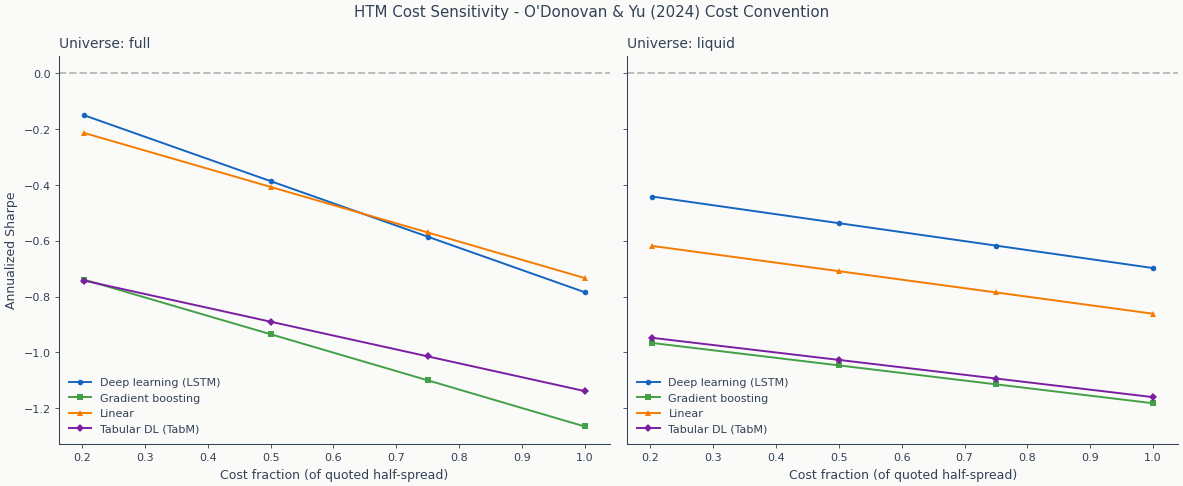

In [12]:
import matplotlib.pyplot as plt

FAMILY_LABELS = {
    "deep_learning": "Deep learning (LSTM)",
    "gbm": "Gradient boosting",
    "linear": "Linear",
    "tabular_dl": "Tabular DL (TabM)",
}
FAMILY_MARKERS = {"deep_learning": "o", "gbm": "s", "linear": "^", "tabular_dl": "D"}
FAMILY_COLORS = {
    "deep_learning": "#1565C0",
    "gbm": "#43A047",
    "linear": "#F57C00",
    "tabular_dl": "#7B1FA2",
}
fig, axes = plt.subplots(1, len(UNIVERSES), figsize=(6 * len(UNIVERSES), 5), sharey=True)
if len(UNIVERSES) == 1:
    axes = [axes]
for i, universe in enumerate(UNIVERSES):
    ax = axes[i]
    subset = cost_df.filter(pl.col("universe") == universe)
    for family in sorted(subset["family"].unique().to_list()):
        line = subset.filter(pl.col("family") == family).sort("cost_fraction")
        ax.plot(
            line["cost_fraction"].to_list(),
            line["sharpe"].to_list(),
            marker=FAMILY_MARKERS[family],
            color=FAMILY_COLORS[family],
            label=FAMILY_LABELS[family],
        )
    ax.axhline(0, color="gray", linestyle="--", alpha=0.5)
    ax.set_xlabel("Cost fraction (of quoted half-spread)")
    ax.set_title(f"Universe: {universe}")
    if i == 0:
        ax.set_ylabel("Annualized Sharpe")
    ax.legend(fontsize=8)

fig.suptitle("HTM Cost Sensitivity - O'Donovan & Yu (2024) Cost Convention")
fig.tight_layout()
fig.show()

## 6. Save Outputs

In [13]:
EVAL_DIR = CASE_DIR / "evaluation"
EVAL_DIR.mkdir(exist_ok=True)
cost_path = EVAL_DIR / "htm_cost_sensitivity.parquet"
cost_df.write_parquet(cost_path)
print(f"Saved {cost_path}")

Saved ~/scratch/ml4t-sp500-r10-14-verifier/sp500_options/evaluation/htm_cost_sensitivity.parquet


## Key Takeaways

1. **HTM avoids the exit-leg spread entirely.** Intrinsic settlement is a
   mechanical cash transfer, not a market order. The only transaction cost is
   the entry spread paid when selling to open. That is the core benefit of
   HTM relative to the 10-day horizon labels, which paid both entry and exit
   bid-ask.

2. **20.3% anchor** (Heston et al. 2023 "algo" case, from Muravyev & Pearson
   2020's $0.026/$0.128 ATM ratio): best-case algorithmic execution realizes
   only a fraction of the quoted half-spread as effective cost. It is lenient toward
   the strategy, not an average. The 50%, 75%, and 100% points capture
   population-average and full-quote-crossing execution respectively.

3. **All 32 combinations are negative.** At the favorable 20.3% fraction,
   accepted LSTM on the full universe is best at Sharpe `-0.1497`; the linear
   champion is `-0.2131`. Each family deteriorates monotonically as the cost
   fraction rises.

4. **The liquid subset does not uniformly mitigate costs.** On this fixed
   top-20 family-champion comparison, two of 16 liquid rows improve on their
   full-universe counterpart. The filter changes the selected trades as well as
   their spreads, so a tighter quote set need not improve portfolio P&L.

5. **What this notebook does NOT claim.** It does not cover delta-hedge
   costs (HTM here is unhedged), index-vol hedging (no SPX/VIX data in this
   CS), or per-contract commissions above the half-spread floor (~$0.65/contract
   is negligible at the premiums we see). It compares highest-IC family
   champions and does not reselect the carrier or touch holdout data.

**Next:** Ch19 verifies that generic risk overlays are not configured for this
HTM case study and leaves the registry unchanged.